In [ ]:
# ================================
# LEUKEMIA MODEL DEVELOPMENT
# YOLOv8 – BINARY CLASSIFICATION
# ALLNeg vs ALLPos
# ================================

# -------- 1. INSTALL DEPENDENCIES --------
!pip install -q ultralytics scikit-learn

# -------- 2. IMPORTS --------
import os
import sys
import csv
import random
import numpy as np
from datetime import datetime
from google.colab import drive
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from PIL import Image

# -------- 3. MOUNT GOOGLE DRIVE --------
drive.mount("/content/drive")

# -------- 4. PREPROCESSING FILE --------
# Save this as preprocessing_leukemia_yolo.py or upload
PREPROCESSING_PATH = "/content/preprocessing_leukemia_yolo.py"
sys.path.append(os.path.dirname(PREPROCESSING_PATH))

import preprocessing_leukemia_yolo
from preprocessing_leukemia_yolo import preprocess_leukemia_yolo

# -------- 5. PATH CONFIGURATION --------
RAW_DATA_DIR = "/content/drive/MyDrive/Research/DataFolder"
DATASET_DIR = "/content/drive/MyDrive/Research/leukemia_cleaned_new"
RESULTS_DIR = "/content/drive/MyDrive/Research/Results_YOLO"
LOG_FILE = os.path.join(RESULTS_DIR, "yolo_training_logs.csv")

os.makedirs(RESULTS_DIR, exist_ok=True)

# -------- 6. RUN PREPROCESSING --------
preprocess_leukemia_yolo(
    input_path=RAW_DATA_DIR,
    output_path=DATASET_DIR
)

# -------- 7. LOAD YOLOv8 CLASSIFICATION MODEL --------
# Options: "yolov8n-cls.pt" (fast) | "yolov8s-cls.pt" (better accuracy)
model = YOLO("yolov8s-cls.pt")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset reorganized
✅ Train / Val / Test split completed


In [ ]:
# -------- 8. TRAIN MODEL --------
EPOCHS = 30

results = model.train(
    data=DATASET_DIR,
    epochs=EPOCHS,
    imgsz=224,
    batch=32,
    device="0",       # change to "0" if GPU is available
    project=RESULTS_DIR,
    name="yolo_leukemia_cls"
)


Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Research/leukemia_cleaned_new, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_leukemia_cls2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

In [ ]:
# -------- 9. VALIDATION (YOLO BUILT-IN) --------
metrics = model.val(data=DATASET_DIR)

print("\n===== YOLO BUILT-IN VALIDATION METRICS =====")
print(f"Top-1 Accuracy : {metrics.top1:.4f}")
print(f"Top-5 Accuracy : {metrics.top5:.4f}")

# -------- 10. DETAILED METRICS (CUSTOM - FIXED) --------
val_dir = os.path.join(DATASET_DIR, "val")
supported_formats = ('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif', '.webp')

image_paths = []
for cls_folder in os.listdir(val_dir):
    cls_path = os.path.join(val_dir, cls_folder)
    if os.path.isdir(cls_path):
        for img_name in os.listdir(cls_path):
            if img_name.lower().endswith(supported_formats):
                image_paths.append(os.path.join(cls_path, img_name))

# IMPORTANT: stream=False
preds = model.predict(
    source=image_paths,
    imgsz=224,
    batch=32,
    verbose=False,
    stream=True
)

y_true, y_prob = [], []
class_map = {"ALLNeg": 0, "ALLPos": 1}

for p in preds:
    # Ground truth
    true_cls_name = os.path.basename(os.path.dirname(p.path))
    y_true.append(class_map[true_cls_name])

    # Get probability for ALLPos safely
    probs = p.probs.data.cpu().numpy()
    y_prob.append(probs[class_map["ALLPos"]])

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob > 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
roc  = roc_auc_score(y_true, y_prob)

print("\n===== DETAILED METRICS =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")

# -------- 11. LOG RESULTS TO CSV --------
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Validation (YOLO built-in)
val_accuracy = metrics.top1

# Test (custom metrics)
test_accuracy = acc
test_precision = prec
test_recall = rec
test_f1 = f1
test_roc_auc = roc

# Model info
epochs_trained = EPOCHS
total_params = sum(p.numel() for p in model.model.parameters())

row = [
    timestamp,
    val_accuracy,
    test_accuracy,
    test_precision,
    test_recall,
    test_f1,
    test_roc_auc,
    epochs_trained,
    total_params
]

header = [
    "Timestamp",
    "Val_Accuracy",
    "Test_Accuracy",
    "Test_Precision",
    "Test_Recall",
    "Test_F1",
    "Test_ROC_AUC",
    "Epochs_Trained",
    "Total_Params"
]

write_header = not os.path.exists(LOG_FILE)

with open(LOG_FILE, "a", newline="") as f:
    writer = csv.writer(f)
    if write_header:
        writer.writerow(header)
    writer.writerow(row)

print(f"\n✅ Metrics logged to: {LOG_FILE}")

# -------- 12. SAVE FINAL MODEL --------
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, "yolo_leukemia_cls_final.pt")
model.save(FINAL_MODEL_PATH)

print(f"\n✅ Final YOLO model saved at: {FINAL_MODEL_PATH}")

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-cls summary (fused): 30 layers, 5,077,762 parameters, 0 gradients, 12.4 GFLOPs
train: /content/drive/MyDrive/Research/leukemia_cleaned_new/train... found 3256 images in 2 classes ✅ 
val: /content/drive/MyDrive/Research/leukemia_cleaned_new/val... found 3031 images in 2 classes ✅ 
test: /content/drive/MyDrive/Research/leukemia_cleaned_new/test... found 3014 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 2.3±1.2 ms, read: 6.0±3.2 MB/s, size: 23.4 KB)
val: Scanning /content/drive/MyDrive/Research/leukemia_cleaned_new/val... 3031 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3031/3031 603.9Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 190/190 6.6it/s 28.9s
                   all      0.999          1
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

===== YOLO BUILT-IN VALIDATION METRICS =====
Top

Successfully loaded model from: /content/drive/MyDrive/Research/Results_YOLO/yolo_leukemia_cls_final.pt
Please upload your image file(s) now:


Saving WBC-Benign-009.jpg to WBC-Benign-009 (1).jpg
Successfully uploaded: /content/WBC-Benign-009 (1).jpg
Making prediction on image: WBC-Benign-009 (1).jpg


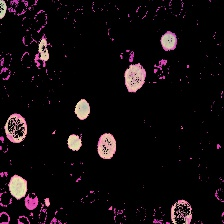


Prediction for WBC-Benign-009 (1).jpg:
  Predicted Class: ALLNeg
  Confidence: 1.0000
  All class probabilities:
    ALLNeg: 1.0000
    ALLPos: 0.0000


In [2]:
# -------- 13. UPLOAD IMAGE AND PREDICT --------
!pip install -q ultralytics # Ensure ultralytics is installed
import os
from PIL import Image
from google.colab import files
import numpy as np
from ultralytics import YOLO # Import YOLO


# Define the path to the saved model
RESULTS_DIR = "/content/drive/MyDrive/Research/Results_YOLO"
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, "yolo_leukemia_cls_final.pt")

# Load the trained YOLO model
if os.path.exists(FINAL_MODEL_PATH):
    model = YOLO(FINAL_MODEL_PATH)
    print(f"Successfully loaded model from: {FINAL_MODEL_PATH}")
else:
    print(f"Error: Final model not found at {FINAL_MODEL_PATH}.")
    print("Please ensure the training process was completed and the model was saved.")
    # Exit or handle error gracefully if model is not found
    exit()

print("Please upload your image file(s) now:")
uploaded = files.upload()

TEST_IMAGE_PATH = None

# Get the name of the first uploaded file
if uploaded:
    for filename in uploaded.keys():
        TEST_IMAGE_PATH = os.path.join("/content", filename)
        print(f"Successfully uploaded: {TEST_IMAGE_PATH}")
        break # We assume only one image will be uploaded for single prediction
else:
    print("No file was uploaded. Skipping prediction.")

if TEST_IMAGE_PATH and os.path.exists(TEST_IMAGE_PATH):
    print(f"Making prediction on image: {os.path.basename(TEST_IMAGE_PATH)}")

    # Display the uploaded image
    img = Image.open(TEST_IMAGE_PATH)
    display(img)

    # Perform prediction
    # The model.predict() method returns a list of Results objects
    results = model.predict(
        source=TEST_IMAGE_PATH,
        imgsz=224,
        verbose=False
    )

    # Process the results for the single image
    for r in results:
        # r.probs contains the probabilities for each class
        probs = r.probs.data.cpu().numpy()
        names = r.names # Get class names

        # Get the predicted class index (highest probability)
        predicted_class_idx = np.argmax(probs)
        predicted_class_name = names[predicted_class_idx]
        confidence = probs[predicted_class_idx]

        print(f"\nPrediction for {os.path.basename(TEST_IMAGE_PATH)}:")
        print(f"  Predicted Class: {predicted_class_name}")
        print(f"  Confidence: {confidence:.4f}")
        print("  All class probabilities:")
        for i, prob in enumerate(probs):
            print(f"    {names[i]}: {prob:.4f}")

else:
    print("Could not proceed with prediction as no image was uploaded or found.")